In [1]:
# tensorboard --logdir=logs
# http://desktop-bu5qmic:6006/

In [2]:
from __future__ import print_function

import argparse
import os
import random
import sys

import numpy as np

In [3]:
import shutil
import os  # Asegúrate de que 'os' esté importado aquí también

# make or reset directory (VERSIÓN MEJORADA)
def mk_reset_dir(directory):
    if os.path.exists(directory):
        try:
            shutil.rmtree(directory)
            os.makedirs(directory) # Usamos makedirs
            print(f"Directorio reseteado: {directory}")
        except Exception as e:
            print(f"Error reseteando: {directory} ({e})")
    else:
        try:
            os.makedirs(directory) # Usamos makedirs
            print(f"Directorio creado: {directory}")
        except Exception as e:
            print(f"Error creando: {directory} ({e})")

In [4]:
# project_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
project_dir = os.getcwd()
print(f"El directorio del proyecto AHORA ES: {project_dir}")

El directorio del proyecto AHORA ES: c:\Users\Usuario\Desktop\proyectoNeumonia


In [5]:
# setting data path data seperated by class name
training_dir = "data\\input\\train"
testing_dir = "data\\input\\test"
validation_dir = "data\\input\\val"

# joining path with parent path 
training_dir = os.path.join(project_dir, training_dir)
testing_dir = os.path.join(project_dir, testing_dir)
validation_dir = os.path.join(project_dir, validation_dir)


# setting output directory
model_dir = "data\\outputs\\models"
log_dir = "data\\outputs\\logs"

# joining path with parent path 
model_dir = os.path.join(project_dir, model_dir)
log_dir = os.path.join(project_dir, log_dir)

In [6]:
model_dir

'c:\\Users\\Usuario\\Desktop\\proyectoNeumonia\\data\\outputs\\models'

In [7]:
# setting training parameters
norm = 255.0
rescale=1./norm
shear_range=0.2
zoom_range=0.2
horizontal_flip=True

# setting train, test, validation parameters
target_size=(224, 224)
batch_size=32
class_mode='categorical'

epochs = 50
verbose = 1

In [8]:
mk_reset_dir(model_dir)
mk_reset_dir(log_dir)

Directorio reseteado: c:\Users\Usuario\Desktop\proyectoNeumonia\data\outputs\models
Directorio reseteado: c:\Users\Usuario\Desktop\proyectoNeumonia\data\outputs\logs


In [36]:
model_file = model_dir+"-weights-{epoch:02d}-val_accuracy-{val_accuracy:.2f}-val_loss-{val_loss:.2f}.keras"

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# data generator for training
train_datagen = ImageDataGenerator(
        rescale=rescale,
        shear_range=shear_range,
        zoom_range=zoom_range,
        horizontal_flip=horizontal_flip)

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode=class_mode)

# data generator for validation
validation_datagen = ImageDataGenerator(rescale=rescale)
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode=class_mode)

# data generator for testing
test_datagen = ImageDataGenerator(rescale=rescale)
test_generator = test_datagen.flow_from_directory(
        testing_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode=class_mode)

Found 5224 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
from keras.applications.inception_v3 import InceptionV3

# importing inception model
base_model = InceptionV3(weights='imagenet', include_top=False)

In [12]:
from keras.layers import Dense, GlobalAveragePooling2D

# setting model layers specially output layer with class number
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

In [13]:
from keras.models import Model

#loading model
model = Model(inputs=base_model.input, outputs=predictions)

In [14]:
# set all laeyrs as untrainable
for layer in base_model.layers:
    layer.trainable = False

In [15]:
from keras import optimizers

# chose and configure optimizer 
sgd = optimizers.Adam()
# sgd = optimizers.SGD()
# sgd = optimizers.SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
# sgd = optimizer=SGD(lr=0.0001, momentum=0.9)

In [16]:
# compile model with optimizer and loss
model.compile(sgd, loss='categorical_crossentropy', metrics=["accuracy"])

In [17]:
#print layers of inception model
for i, layer in enumerate(base_model.layers):
    print(i, layer.name)

0 input_layer
1 conv2d
2 batch_normalization
3 activation
4 conv2d_1
5 batch_normalization_1
6 activation_1
7 conv2d_2
8 batch_normalization_2
9 activation_2
10 max_pooling2d
11 conv2d_3
12 batch_normalization_3
13 activation_3
14 conv2d_4
15 batch_normalization_4
16 activation_4
17 max_pooling2d_1
18 conv2d_8
19 batch_normalization_8
20 activation_8
21 conv2d_6
22 conv2d_9
23 batch_normalization_6
24 batch_normalization_9
25 activation_6
26 activation_9
27 average_pooling2d
28 conv2d_5
29 conv2d_7
30 conv2d_10
31 conv2d_11
32 batch_normalization_5
33 batch_normalization_7
34 batch_normalization_10
35 batch_normalization_11
36 activation_5
37 activation_7
38 activation_10
39 activation_11
40 mixed0
41 conv2d_15
42 batch_normalization_15
43 activation_15
44 conv2d_13
45 conv2d_16
46 batch_normalization_13
47 batch_normalization_16
48 activation_13
49 activation_16
50 average_pooling2d_1
51 conv2d_12
52 conv2d_14
53 conv2d_17
54 conv2d_18
55 batch_normalization_12
56 batch_normalization_

In [18]:
# train the top 2 inception blocks 
# freeze first 249 layers
# unfreeze the rest

for layer in model.layers[:249]:
    layer.trainable = False
for layer in model.layers[249:]:
    layer.trainable = True

In [37]:
import keras

checkpoint = keras.callbacks.ModelCheckpoint(
    model_file, 
    monitor='val_loss',
    verbose=1, 
    save_best_only=True,
    mode='min'
)

In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    min_delta=0, 
    patience=10,  # Le damos 10 épocas de paciencia
    verbose=1, 
    mode='min'
)

In [21]:
tensorboard = keras.callbacks.TensorBoard(
    log_dir=log_dir, 
    histogram_freq=0, 
    write_graph=True, 
    write_images=False
)

In [38]:
callbacks_list = [checkpoint, tensorboard, early_stopping]
# callbacks_list = [checkpoint, tensorboard]

In [40]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=callbacks_list
)

Epoch 1/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9724 - loss: 0.0858
Epoch 1: val_loss improved from None to 0.06881, saving model to c:\Users\Usuario\Desktop\proyectoNeumonia\data\outputs\models-weights-01-val_accuracy-1.00-val_loss-0.07.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 604s 3s/step - accuracy: 0.9732 - loss: 0.0787 - val_accuracy: 1.0000 - val_loss: 0.0688
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9804 - loss: 0.0568
Epoch 2: val_loss did not improve from 0.06881
164/164 ━━━━━━━━━━━━━━━━━━━━ 442s 3s/step - accuracy: 0.9765 - loss: 0.0675 - val_accuracy: 0.7500 - val_loss: 0.5021
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9802 - loss: 0.0626
Epoch 3: val_loss did not improve from 0.06881
164/164 ━━━━━━━━━━━━━━━━━━━━ 430s 3s/step - accuracy: 0.9772 - loss: 0.0682 - val_accuracy: 0.9375 - val_loss: 0.1383
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9770 - loss: 0.0585
Epoch 4: val_loss did not improve fr

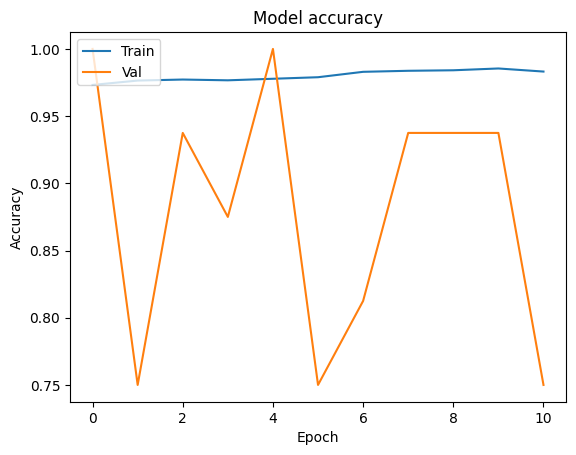

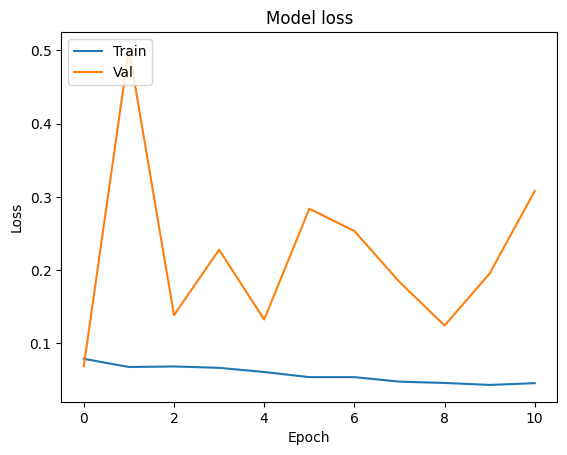

In [41]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values

# CORRECCIÓN: 'acc' se reemplaza por 'accuracy'
plt.plot(history.history['accuracy'])
# CORRECCIÓN: 'val_acc' se reemplaza por 'val_accuracy'
plt.plot(history.history['val_accuracy']) 

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
# Estos nombres usualmente no cambian
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [ ]:
#Retraining

In [ ]:
# setting retraining from old model
model_path = project_dir+"\\data\\outputs\\models\\"+"modelsweights-03-val_acc-0.89-val_loss-0.28.hdf5"
epochs=15
verbose=1

model = keras.models.load_model(model_path)

# retrain by loading last good model
history = model.fit_generator(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=callbacks_list)

In [44]:
# testing model

# 1. Pega aquí la "Ruta Relativa" que copiaste del explorador de archivos
ruta_relativa_del_modelo = r"data\outputs\models-weights-01-val_accuracy-1.00-val_loss-0.07.keras"

# 2. Convertimos la ruta relativa en una ruta absoluta
model_path = os.path.join(project_dir, ruta_relativa_del_modelo)

print(f"Cargando modelo desde: {model_path}")
model = keras.models.load_model(model_path)

print("¡Modelo cargado exitosamente!")

Cargando modelo desde: c:\Users\Usuario\Desktop\proyectoNeumonia\data\outputs\models-weights-01-val_accuracy-1.00-val_loss-0.07.keras
¡Modelo cargado exitosamente!


In [46]:
result = model.evaluate(test_generator, verbose=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9263 - loss: 0.2588


In [47]:
print("%s%.2f%s"% ("Accuracy: ", result[1]*100, "%"))
print("%s%.2f"% ("Loss: ", result[0]))

Accuracy: 92.63%
Loss: 0.26


20/20 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step
Nombres de clases encontrados: ['NORMAL', 'PNEUMONIA']

 REPORTE DE CLASIFICACIÓN (Classification Report)
              precision    recall  f1-score   support

      NORMAL       0.35      0.31      0.33       234
   PNEUMONIA       0.61      0.66      0.64       390

    accuracy                           0.53       624
   macro avg       0.48      0.48      0.48       624
weighted avg       0.52      0.53      0.52       624


 MATRIZ DE CONFUSIÓN (Confusion Matrix)


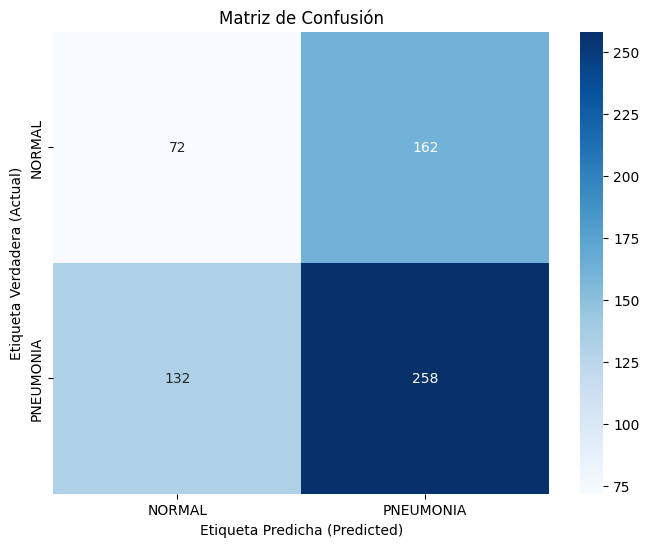

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras # O 'import keras' si usas Keras 2

# --- 1. CARGA TU MEJOR MODELO ---
# (Asegúrate de que esta ruta sea correcta, usa la que te funcionó en la Celda 27)
model_path = os.path.join(project_dir, r"data\outputs\models-weights-01-val_accuracy-1.00-val_loss-0.07.keras") # 
model = keras.models.load_model(model_path)


# --- 2. OBTENER PREDICCIONES Y ETIQUETAS REALES ---
# Le pedimos al 'test_generator' que nos dé todas las imágenes
# IMPORTANTE: Pon 'shuffle=False' para que las predicciones y las etiquetas no se mezclen.
test_generator.reset() # Reiniciar el generador
test_generator.shuffle = False

# Obtener las predicciones (probabilidades)
y_pred_prob = model.predict(test_generator)

# Convertir probabilidades (ej. [0.1, 0.9]) a la clase final (ej. 1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Obtener las etiquetas verdaderas
y_true = test_generator.classes

# Obtener los nombres de las clases (ej. {'NORMAL': 0, 'PNEUMONIA': 1})
class_names = list(test_generator.class_indices.keys())
print(f"Nombres de clases encontrados: {class_names}")


# --- 3. CALCULAR MÉTRICAS Y MOSTRAR REPORTE ---
print("\n" + "="*50)
print(" REPORTE DE CLASIFICACIÓN (Classification Report)")
print("="*50)
# ¡Esto calcula tu Precisión y Sensibilidad automáticamente!
print(classification_report(y_true, y_pred, target_names=class_names))


# --- 4. CALCULAR Y DIBUJAR LA MATRIZ DE CONFUSIÓN ---
print("\n" + "="*50)
print(" MATRIZ DE CONFUSIÓN (Confusion Matrix)")
print("="*50)

cm = confusion_matrix(y_true, y_pred)
# print(cm) # Imprime la matriz en modo texto

# Dibujar la matriz con colores usando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Verdadera (Actual)')
plt.xlabel('Etiqueta Predicha (Predicted)')
plt.show()